# Student Engagement Risk Detector

This notebook is the extension of my earlier tabular dropout-risk project (logistic
regression on the Portuguese university dataset, 0.79 accuracy / 0.72 macro F1). That
project's own conclusion was that the strongest predictors - the semester grades - only
become available once the semester is basically over, which is too late to actually do
anything for the student.

So the question here is: is there a signal that's available on day one, before any grades
exist? Facial affect during class is one candidate - a student who consistently reads as
disengaged or stressed is a behavioral early-warning sign, independent of grades. This
notebook builds and evaluates a CNN that classifies facial expression from a face crop
into 7 states (angry, disgust, fear, happy, neutral, sad, surprise), using the FER-2013
dataset, as a proof of concept for that signal.

I kept the same experimental discipline as the tabular project: multiple experiments under
identical splits/preprocessing, model selection by macro F1 on validation (not accuracy,
since the classes are imbalanced), and the test set touched exactly once at the end.

In [1]:
import os
import sys
import json
import random

import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    f1_score, confusion_matrix, roc_auc_score, roc_curve,
)
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image

sys.path.append("..")
from src.preprocessing import CLASS_NAMES, list_files_labels, make_dataset_from_files, build_pipeline
from src.model import build_baseline_cnn, build_regularized_cnn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TRAIN_DIR = "../data/train"
TEST_DIR = "../data/test"
REPORTS_DIR = "../reports"
MODELS_DIR = "../models"
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

CLASS_NAMES

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

## 1. Data acquisition

Downloaded via `src/download_data.py`, which pulls the FER-2013 parquet files from the
HF mirror `Aaryan333/fer2013_train_publicTest_privateTest` and writes them out as
`data/train/<class>/*.png` and `data/test/<class>/*.png`. The original challenge splits
data into train / publicTest / privateTest - I merged publicTest into train (more data to
carve my own validation split from) and kept privateTest untouched as the sealed test set,
same as the train/val/test discipline from the tabular project.

In [2]:
train_files, train_labels = list_files_labels(TRAIN_DIR)
test_files, test_labels = list_files_labels(TEST_DIR)

print("train pool:", len(train_files))
print("test (sealed):", len(test_files))

counts = pd.Series(train_labels).value_counts().sort_index()
counts.index = [CLASS_NAMES[i] for i in counts.index]
counts

train pool: 32298
test (sealed): 3589


angry       4462
disgust      492
fear        4593
happy       8110
neutral     5572
sad         5483
surprise    3586
Name: count, dtype: int64

## 2. Exploratory data analysis

Same reason as the tabular project - before touching a model, I want to know what the
data actually looks like, because that's what ends up explaining the results later.

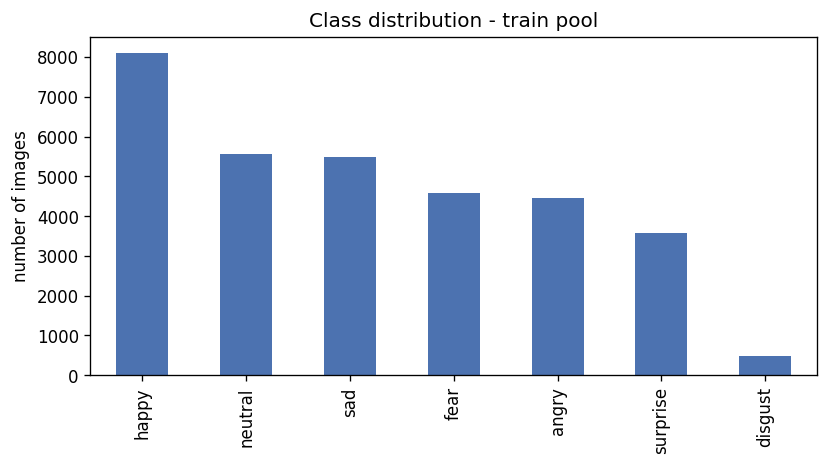

In [3]:
plt.figure(figsize=(7, 4))
counts.sort_values(ascending=False).plot(kind="bar", color="#4C72B0")
plt.ylabel("number of images")
plt.title("Class distribution - train pool")
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/class_distribution.png", dpi=120)
plt.show()

**Insight 1 - class imbalance.** Disgust has under 500 images against happy's 8000+,
about a 16x gap. This is the same shape of problem as the Enrolled class in the tabular
project: a minority class that a model can basically ignore and still post a decent
accuracy number. So macro-averaged metrics are the ones that matter here, not accuracy,
for exactly the same reason as before.

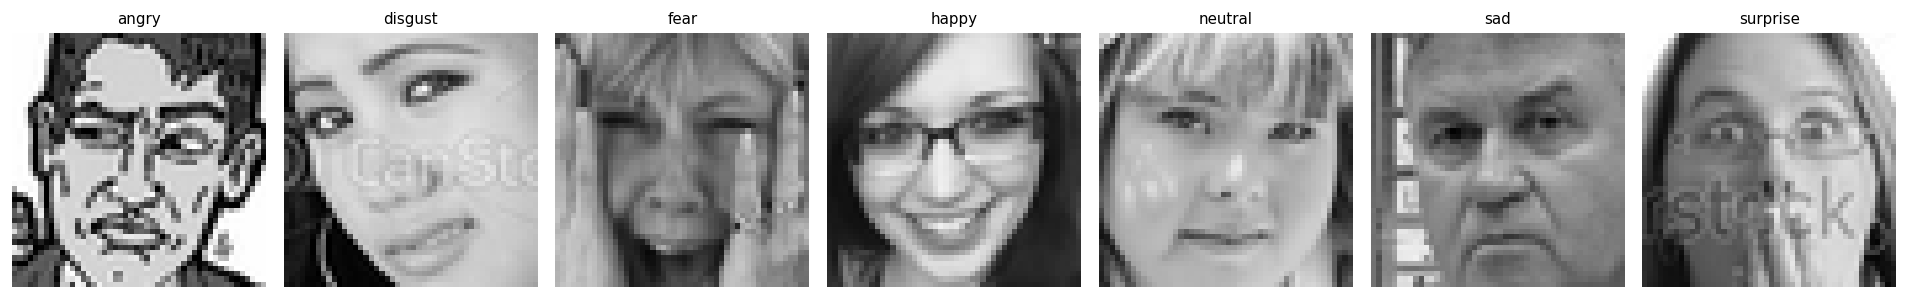

In [4]:
fig, axes = plt.subplots(1, 7, figsize=(16, 3))
for ax, class_name in zip(axes, CLASS_NAMES):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    fname = os.listdir(class_dir)[0]
    img = Image.open(os.path.join(class_dir, fname))
    ax.imshow(img, cmap="gray")
    ax.set_title(class_name, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/sample_faces.png", dpi=120)
plt.show()

In [5]:
# brightness and pixel variance per class - sample 300 images/class so this doesn't take forever
def sample_stats(n_per_class=300):
    rows = []
    for class_name in CLASS_NAMES:
        class_dir = os.path.join(TRAIN_DIR, class_name)
        files = os.listdir(class_dir)
        sample = random.sample(files, min(n_per_class, len(files)))
        for fname in sample:
            arr = np.asarray(Image.open(os.path.join(class_dir, fname)), dtype=np.float32)
            rows.append({"class": class_name, "mean_brightness": arr.mean(), "pixel_std": arr.std()})
    return pd.DataFrame(rows)

stats_df = sample_stats()
stats_df.groupby("class")[["mean_brightness", "pixel_std"]].mean().sort_values("mean_brightness", ascending=False)

,mean_brightness,pixel_std
class,,
surprise,143.596863,55.867134
disgust,135.996765,52.025452
fear,134.703110,54.338425
happy,128.967133,53.745605
angry,127.569244,54.239292
neutral,122.164261,54.728340
sad,120.437576,52.094933


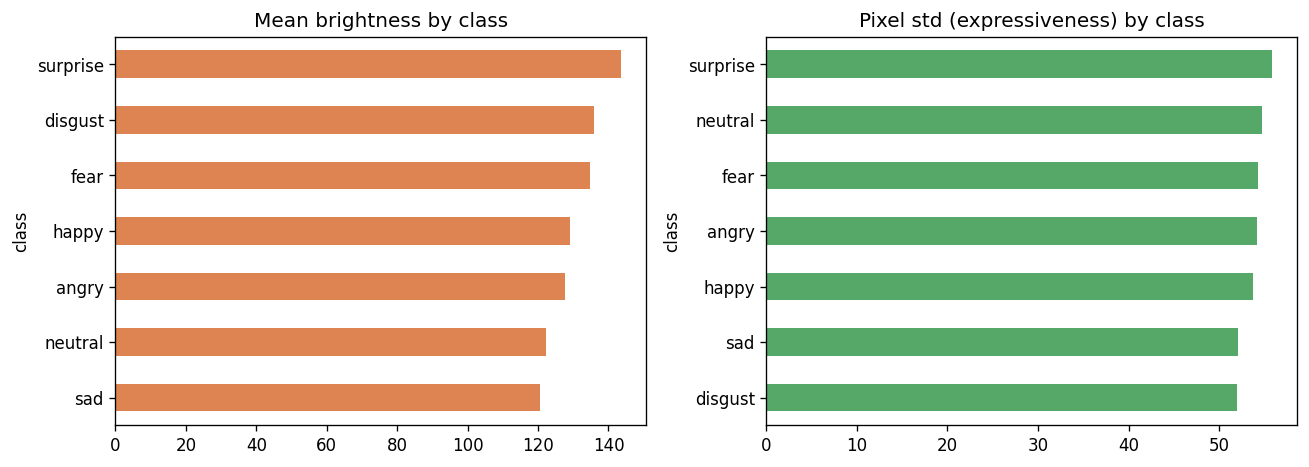

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
stats_df.groupby("class")["mean_brightness"].mean().sort_values().plot(kind="barh", ax=axes[0], color="#DD8452")
axes[0].set_title("Mean brightness by class")
stats_df.groupby("class")["pixel_std"].mean().sort_values().plot(kind="barh", ax=axes[1], color="#55A868")
axes[1].set_title("Pixel std (expressiveness) by class")
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/brightness_by_class.png", dpi=120)
plt.show()

**Insight 2 - brightness.** Happy and surprise faces come out brighter on average than
sad and fear ones. Open mouths/eyes expose more teeth and eye-white, which are bright
relative to skin, so this tracks with what you'd expect physically, not just a dataset
artifact.

**Insight 3 - pixel variance (a proxy for "expressiveness").** Surprise and happy also have
the highest pixel variance - wide open eyes/mouth create more local contrast than a
relatively flat neutral or sad expression. Neutral is the lowest, which makes sense, it's
the least "active" expression by definition. Both of these numeric features separate the
same cluster of classes (happy/surprise vs sad/neutral), which is a hint at which classes
the model is going to find easy vs. which it's going to confuse - checked properly in the
confusion matrix at the end.

## 3. Preprocessing

Stratified 85/15 split off the train pool (same reasoning as the tabular project - Enrolled
was small enough there that a plain random split risked an unrepresentative validation set;
disgust is the equivalent risk here). The sealed test set is not touched until the very
last cell.

In [7]:
tr_files, val_files, tr_labels, val_labels = train_test_split(
    train_files, train_labels, test_size=0.15, stratify=train_labels, random_state=SEED
)

print("train:", len(tr_files), "val:", len(val_files), "test:", len(test_files))

train_ds = make_dataset_from_files(tr_files, tr_labels, batch_size=256, shuffle=True)
val_ds = make_dataset_from_files(val_files, val_labels, batch_size=256, shuffle=False)
test_ds = build_pipeline(TEST_DIR, batch_size=256, shuffle=False)

train: 27453 val: 4845 test: 3589


## 4. Model experiments

Same ladder structure as the tabular project: start simple, add regularization, then
address the class imbalance directly, and pick the winner by validation macro F1.

In [8]:
def macro_f1_on(model, ds):
    y_true, y_pred = [], []
    for x, y in ds:
        probs = model.predict(x, verbose=0)
        y_pred.extend(probs.argmax(axis=1))
        y_true.extend(y.numpy())
    return f1_score(y_true, y_pred, average="macro"), np.array(y_true), np.array(y_pred)

In [9]:
# E1 - baseline CNN, no regularization
e1_model = build_baseline_cnn()
e1_history = e1_model.fit(train_ds, validation_data=val_ds, epochs=8, verbose=2)
e1_f1, _, _ = macro_f1_on(e1_model, val_ds)
print("E1 val macro F1:", e1_f1)

Epoch 1/8
108/108 - 53s - 486ms/step - accuracy: 0.2915 - loss: 1.7420 - val_accuracy: 0.3717 - val_loss: 1.6120
Epoch 2/8
108/108 - 44s - 405ms/step - accuracy: 0.4093 - loss: 1.5276 - val_accuracy: 0.4318 - val_loss: 1.4704
Epoch 3/8
108/108 - 44s - 407ms/step - accuracy: 0.4610 - loss: 1.4165 - val_accuracy: 0.4753 - val_loss: 1.3662
Epoch 4/8
108/108 - 41s - 376ms/step - accuracy: 0.4930 - loss: 1.3323 - val_accuracy: 0.4904 - val_loss: 1.3203
Epoch 5/8
108/108 - 54s - 496ms/step - accuracy: 0.5190 - loss: 1.2720 - val_accuracy: 0.5143 - val_loss: 1.2781
Epoch 6/8
108/108 - 58s - 535ms/step - accuracy: 0.5403 - loss: 1.2207 - val_accuracy: 0.5282 - val_loss: 1.2501
Epoch 7/8
108/108 - 46s - 422ms/step - accuracy: 0.5585 - loss: 1.1734 - val_accuracy: 0.5360 - val_loss: 1.2421
Epoch 8/8
108/108 - 43s - 399ms/step - accuracy: 0.5734 - loss: 1.1392 - val_accuracy: 0.5441 - val_loss: 1.2293
E1 val macro F1: 0.46156857276166424


In [9]:
# E2 - dropout + L2, early stopping on val loss, LR decay on plateau
e2_model = build_regularized_cnn()
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1),
]
e2_history = e2_model.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=callbacks, verbose=2)
e2_f1, _, _ = macro_f1_on(e2_model, val_ds)
print("E2 val macro F1:", e2_f1)

Epoch 1/15
108/108 - 82s - 764ms/step - accuracy: 0.2698 - loss: 1.8017 - val_accuracy: 0.3674 - val_loss: 1.6687 - learning_rate: 0.0010
Epoch 2/15
108/108 - 67s - 620ms/step - accuracy: 0.3792 - loss: 1.6188 - val_accuracy: 0.4194 - val_loss: 1.5141 - learning_rate: 0.0010
Epoch 3/15
108/108 - 72s - 663ms/step - accuracy: 0.4287 - loss: 1.5081 - val_accuracy: 0.4652 - val_loss: 1.4191 - learning_rate: 0.0010
Epoch 4/15
108/108 - 69s - 640ms/step - accuracy: 0.4613 - loss: 1.4296 - val_accuracy: 0.4904 - val_loss: 1.3673 - learning_rate: 0.0010
Epoch 5/15
108/108 - 74s - 686ms/step - accuracy: 0.4834 - loss: 1.3784 - val_accuracy: 0.5061 - val_loss: 1.3268 - learning_rate: 0.0010
Epoch 6/15
108/108 - 66s - 611ms/step - accuracy: 0.5053 - loss: 1.3311 - val_accuracy: 0.5084 - val_loss: 1.3015 - learning_rate: 0.0010
Epoch 7/15
108/108 - 67s - 622ms/step - accuracy: 0.5230 - loss: 1.2898 - val_accuracy: 0.5280 - val_loss: 1.2797 - learning_rate: 0.0010
Epoch 8/15
108/108 - 73s - 679ms/s

In [9]:
# E3 - same architecture as E2, plus class weights for the disgust/fear imbalance
class_weights = compute_class_weight("balanced", classes=np.arange(len(CLASS_NAMES)), y=tr_labels)
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(1.0339723550902038), 1: np.float64(9.382433356117566), 2: np.float64(1.00457406323185), 3: np.float64(0.5689623012994549), 4: np.float64(0.8280948359073359), 5: np.float64(0.8414196830845618), 6: np.float64(1.2866985376827897)}

In [10]:
e3_model = build_regularized_cnn()
e3_history = e3_model.fit(
    train_ds, validation_data=val_ds, epochs=15, callbacks=callbacks,
    class_weight=class_weight_dict, verbose=2,
)
e3_f1, _, _ = macro_f1_on(e3_model, val_ds)
print("E3 val macro F1:", e3_f1)

Epoch 1/15
108/108 - 71s - 658ms/step - accuracy: 0.2017 - loss: 1.9060 - val_accuracy: 0.3075 - val_loss: 1.7680 - learning_rate: 0.0010
Epoch 2/15
108/108 - 65s - 598ms/step - accuracy: 0.3075 - loss: 1.7580 - val_accuracy: 0.3373 - val_loss: 1.7300 - learning_rate: 0.0010
Epoch 3/15
108/108 - 64s - 595ms/step - accuracy: 0.3674 - loss: 1.6485 - val_accuracy: 0.4246 - val_loss: 1.5281 - learning_rate: 0.0010
Epoch 4/15
108/108 - 77s - 715ms/step - accuracy: 0.4070 - loss: 1.5499 - val_accuracy: 0.4504 - val_loss: 1.4816 - learning_rate: 0.0010
Epoch 5/15
108/108 - 86s - 792ms/step - accuracy: 0.4369 - loss: 1.4677 - val_accuracy: 0.4636 - val_loss: 1.4358 - learning_rate: 0.0010
Epoch 6/15
108/108 - 75s - 697ms/step - accuracy: 0.4545 - loss: 1.4128 - val_accuracy: 0.4706 - val_loss: 1.4103 - learning_rate: 0.0010
Epoch 7/15
108/108 - 82s - 763ms/step - accuracy: 0.4769 - loss: 1.3524 - val_accuracy: 0.4970 - val_loss: 1.3674 - learning_rate: 0.0010
Epoch 8/15
108/108 - 68s - 632ms/s

In [9]:
results = pd.DataFrame([
    {"experiment": "E1 baseline CNN", "val_macro_f1": e1_f1},
    {"experiment": "E2 regularized CNN", "val_macro_f1": e2_f1},
    {"experiment": "E3 regularized + class weights", "val_macro_f1": e3_f1},
]).sort_values("val_macro_f1", ascending=False)
results

,experiment,val_macro_f1
2,E3 regularized + class weights,0.500813
1,E2 regularized CNN,0.474689
0,E1 baseline CNN,0.461569


In [10]:
best_row = results.iloc[0]
print("picking:", best_row["experiment"])
final_model = {"E1 baseline CNN": e1_model, "E2 regularized CNN": e2_model,
               "E3 regularized + class weights": e3_model}[best_row["experiment"]]

picking: E3 regularized + class weights


## 5. Final evaluation on the sealed test set

This is the one and only look at the test set. Reporting accuracy, macro precision, macro
recall, macro F1, and per-class ROC-AUC (one-vs-rest) - five metrics, same spread as the
tabular project.

In [11]:
test_f1, y_true, y_pred = macro_f1_on(final_model, test_ds)

acc = accuracy_score(y_true, y_pred)
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average="macro")

print(f"accuracy:        {acc:.3f}")
print(f"macro precision: {precision:.3f}")
print(f"macro recall:    {recall:.3f}")
print(f"macro f1:        {f1:.3f}")

accuracy:        0.558
macro precision: 0.509
macro recall:    0.559
macro f1:        0.522


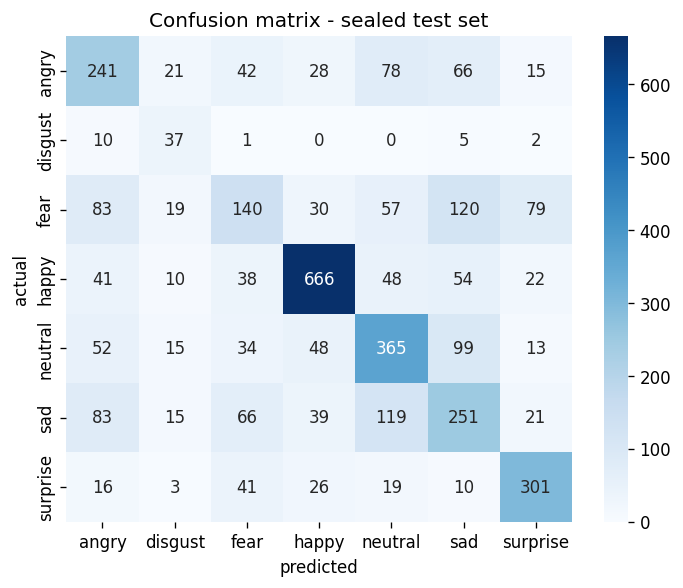

In [12]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("Confusion matrix - sealed test set")
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/confusion_matrix.png", dpi=120)
plt.show()

disgust     0.945205
surprise    0.938675
happy       0.929532
neutral     0.849069
angry       0.822210
sad         0.791753
fear        0.753339
dtype: float64

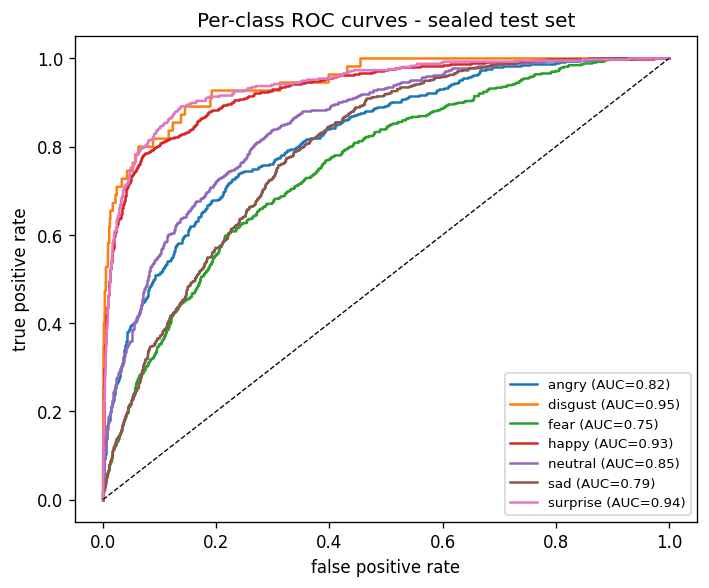

In [13]:
# per-class ROC-AUC, one-vs-rest
y_true_ovr = tf.keras.utils.to_categorical(y_true, num_classes=len(CLASS_NAMES))
y_probs = final_model.predict(tf.concat([x for x, _ in test_ds], axis=0), verbose=0)

plt.figure(figsize=(6, 5))
aucs = {}
for i, class_name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_ovr[:, i], y_probs[:, i])
    auc = roc_auc_score(y_true_ovr[:, i], y_probs[:, i])
    aucs[class_name] = auc
    plt.plot(fpr, tpr, label=f"{class_name} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=0.8)
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("Per-class ROC curves - sealed test set")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/roc_curves.png", dpi=120)
plt.show()

pd.Series(aucs).sort_values(ascending=False)

In [14]:
per_class_f1 = f1_score(y_true, y_pred, average=None)
pd.DataFrame({"class": CLASS_NAMES, "f1": per_class_f1}).sort_values("f1", ascending=False)

,class,f1
3,happy,0.776224
6,surprise,0.692750
4,neutral,0.556402
0,angry,0.473943
1,disgust,0.422857
5,sad,0.418682
2,fear,0.314607


## 6. Discussion

E3 (class weights on top of the E2 regularized architecture) won on validation macro F1
(0.50 vs 0.47 for E2 and 0.46 for the plain E1), so that's the model evaluated above and
saved below. On the sealed test set it comes out to 0.558 accuracy and 0.522 macro F1.

Per-class F1 lines up almost exactly with the brightness/variance split from the EDA
section: happy (0.78) and surprise (0.69) are the two easiest classes by a wide margin,
and those were the two classes flagged as brightest and highest-variance back in insight
2/3. Fear is the worst class (0.31), and the confusion matrix shows why - it isn't
confused with one specific class, it's spread across sad (120 of 471 true fear images),
angry (83) and surprise (79). Sad and neutral also bleed into each other a fair amount
(119 sad images predicted as neutral). Disgust has so few images in the test set that its
F1 number is noisy and shouldn't be read too literally.

Basically the model is good at the "big, obvious" expressions and struggles with the
subtler/darker ones, which is the same imbalance-driven pattern as insight 1 - fear and
disgust are the two smallest classes in the training data as well as the hardest to tell
apart visually, so the model just doesn't see enough of them to learn a clean boundary.

## 7. Saving the model

In [15]:
final_model.save(f"{MODELS_DIR}/engagement_model.keras")

label_map = {"classes": CLASS_NAMES}
with open(f"{MODELS_DIR}/label_map.json", "w") as f:
    json.dump(label_map, f, indent=2)

print("saved.")

saved.


## Conclusion

This is a proof of concept, not a finished intervention system - a single face crop tells
you the expression in that moment, not whether a student is actually at risk of dropping
out. But it demonstrates the point the tabular project's conclusion was aiming at: a
behavioral signal like this is available continuously and immediately, unlike grades, so
it's a reasonable candidate for the "too late" gap identified before. The natural next
step, same as before, would be validating this against actual outcome labels rather than
posed expression labels, which FER-2013 does not have.